In [1]:
import numpy as np
np.random.seed(167834359)
import pandas as pd
import scipy.stats as stats
from scipy.special import gamma
import scipy.integrate as integrate
import tqdm

%matplotlib inline
import matplotlib.pyplot as plt
plt.rcParams.update({
    "text.usetex": True,
    "font.family": "serif",
    "font.serif": ["Computer Modern Roman"],
    "font.size": 12,
    })

from astropy.time import Time
msol_to_erg = 1.787624e54
Mpc_to_cm = 3.8057e24

# load EOS
m_val, r_val, l_val = np.loadtxt("../../eos/RMF3_MRL.dat", unpack=True)
mtov = m_val.max()
r16 = np.interp(1.6, m_val, r_val)

In [14]:
df_narrow_grb = pd.read_csv("./grb_params_narrow.dat", sep=" ")
df_wide_grb = pd.read_csv("./grb_params_wide.dat", sep=" ")

How to load the Fermi GBM catalog

https://heasarc.gsfc.nasa.gov/cgi-bin/W3Browse/w3catindex.pl#FERMI -> FERMI GBM catalog

Limit results to -> set no limit on rows -> start search

sort after name trigger_time if you want to

Download table via "Save all objects to File"



In [15]:
fermi_df = pd.read_csv("./data/FERMI_GBM_samples.txt", sep="|", header=2, na_values=["", " ", "          ", "        ", "\t"])
fermi_df.columns = fermi_df.columns.str.replace(' ', '')
delta_t = (Time(fermi_df['trigger_time'].iloc[-1], format="iso").mjd - Time(fermi_df['trigger_time'].iloc[0], format="iso").mjd) / 365.25

mask = pd.to_numeric(fermi_df["t90"]) < 2

fermi_df = fermi_df.loc[mask]

bins = np.geomspace(-8, -4, 25)
hist_fermi, fermi_bins = np.histogram(np.log10(pd.to_numeric(fermi_df['fluence'])), bins=bins)
hist_fermi = hist_fermi / delta_t
#hist_fermi = np.cumsum(hist_fermi[::-1])[::-1]

In [16]:
def log10_fluence(df):
    fluence = df["log10_Egamma_fermi_gbm"] + np.log10( (1+df['redshift']) / (4*np.pi*df["luminosity_distance"]**2 * Mpc_to_cm**2))

    fluence = fluence[(fluence>-8) & df["has_grb"]]
    return fluence

log10fluence_narrow = log10_fluence(df_narrow_grb)
log10fluence_wide = log10_fluence(df_wide_grb)


hist_narrow, narrow_bins = np.histogram(log10fluence_narrow, bins=bins)
hist_wide, wide_bins = np.histogram(log10fluence_wide, bins=bins)

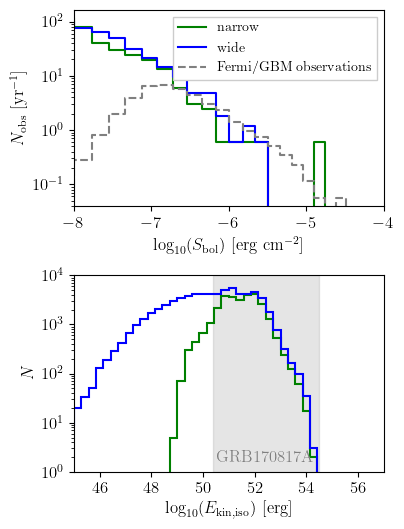

In [17]:
fig, ax = plt.subplots(2, 1, figsize=(4, 6))
fig.subplots_adjust(hspace=0.35)
ax[0].step(narrow_bins[:-1], hist_narrow *0.6, color="green", label="narrow")
ax[0].step(wide_bins[:-1], hist_wide *0.6, color="blue", label="wide")
ax[0].step(fermi_bins[:-1], hist_fermi, color="grey", label="Fermi/GBM observations", linestyle="dashed")

#ax[0].hist(log10fluence_wide, cumulative=0, histtype="step", color="orange", bins=bins, label="wide")
ax[0].set(yscale="log", ylabel="$N_{\\rm{obs}}$ [yr$^{-1}$]", xlim=(-8, -4), xlabel="$\\log_{10}(S_{\\rm{bol}})$ [erg cm$^{-2}$]")
ax[0].legend(framealpha=1, fancybox=False, fontsize=10)

ax[1].hist(df_narrow_grb["log10_Ekin_iso"][df_narrow_grb["has_grb"]], histtype="step", color="green", bins=np.linspace(43, 57, 50), cumulative=0, linewidth=1.5)
ax[1].hist(df_wide_grb["log10_Ekin_iso"][df_wide_grb["has_grb"]], histtype="step", color="blue", bins=np.linspace(43, 57, 50), cumulative=0, linewidth=1.5)
ax[1].set(yscale="log", xlim=(45, 57), ylim=(1, 1e4), xlabel="$\\log_{10}(E_{\\rm{kin, iso}})$ [erg]", ylabel="$N$")
ax[1].fill_betweenx(ax[1].get_ylim(), 52.2-1.8, 52.2+2.3, color="grey", alpha=0.2)
ax[1].text(0.46, 0.05, "GRB170817A", transform=ax[1].transAxes, color="grey")

fig.savefig("../../figures/grb_population.pdf", dpi=250, bbox_inches="tight")

In [3]:
df_narrow_grb[["inclination_EM", "log10_n0"]].to_csv("narrow_inclination_density.dat", sep=" ")

In [4]:
df_wide_grb[["inclination_EM", "log10_n0"]].to_csv("wide_inclination_density.dat", sep=" ")

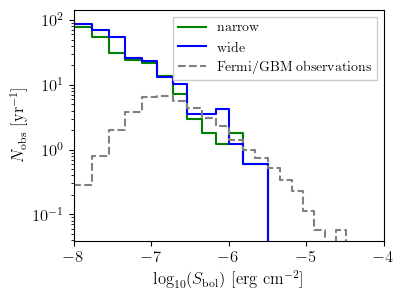

In [6]:
fig, ax = plt.subplots(1, 1, figsize=(4, 3))
fig.subplots_adjust(hspace=0.35)
ax.step(narrow_bins[:-1], hist_narrow *0.6, color="green", label="narrow")
ax.step(wide_bins[:-1], hist_wide *0.6, color="blue", label="wide")
ax.step(fermi_bins[:-1], hist_fermi, color="grey", label="Fermi/GBM observations", linestyle="dashed")

ax.set(yscale="log", ylabel="$N_{\\rm{obs}}$ [yr$^{-1}$]", xlim=(-8, -4), xlabel="$\\log_{10}(S_{\\rm{bol}})$ [erg cm$^{-2}$]")
ax.legend(framealpha=1, fancybox=False, fontsize=10)